# 01 — Wavelet Transform cơ bản

Notebook này minh họa các khái niệm trong `docs/03_research/wavelet_theory.md`
và `docs/03_research/wavelet_transform.md`:

- Thực hiện Discrete Wavelet Transform (DWT) trên một ảnh thật.
- Trực quan hóa 4 thành phần **LL / LH / HL / HH**.
- Phân rã nhiều mức (multi-level decomposition).
- Tái tạo lại ảnh từ hệ số wavelet (kiểm tra tính khả nghịch).
- So sánh nhanh độ tương đồng giữa hai ảnh bằng hệ số wavelet.

> Yêu cầu: `pip install PyWavelets numpy pillow matplotlib scikit-image`



In [ ]:
import sys, os
sys.path.insert(0, os.path.abspath(".."))

import numpy as np
import matplotlib.pyplot as plt

from src.wavelet.wavelet_transform import (
    load_image_grayscale,
    wavedec2_image,
    get_subbands,
    reconstruct_image,
    normalize_for_display,
    wavelet_similarity,
    max_dwt_level,
)

%matplotlib inline


## 1. Đọc ảnh đầu vào

Dùng ảnh thật trong dataset của nhóm: `data/input/similar/pair_01/image_01.jpg`.
Ảnh được chuyển về grayscale, giá trị float trong khoảng [0, 1] bằng
`load_image_grayscale` (module TV2).


Da doc anh tu dataset: ../data/input/similar/pair_01/image_01.jpg
Kich thuoc anh: (300, 400) | dtype: float64


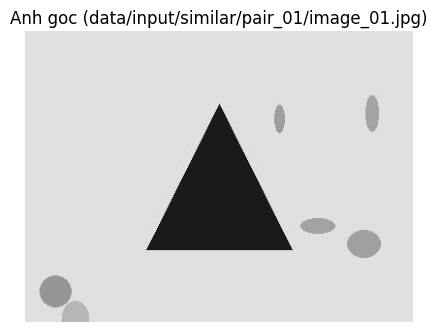

In [ ]:
DATASET_IMAGE = os.path.join("..", "data", "input", "similar", "pair_01", "image_01.jpg")

if os.path.exists(DATASET_IMAGE):
    image = load_image_grayscale(DATASET_IMAGE)
    print("Da doc anh tu dataset:", DATASET_IMAGE)
else:
    print(f"[Canh bao] Khong tim thay {DATASET_IMAGE}, dung tam anh mau skimage.data.camera()")
    from skimage import data, img_as_float
    image = img_as_float(data.camera())

print("Kich thuoc anh:", image.shape, "| dtype:", image.dtype)

plt.figure(figsize=(5, 5))
plt.imshow(image, cmap="gray")
plt.title("Anh goc (data/input/similar/pair_01/image_01.jpg)")
plt.axis("off")
plt.show()


## 2. DWT mức 1 (level = 1) với wavelet `db4`

Theo đúng lời gọi hàm đã thống nhất trong nhóm:

```python
coeffs = pywt.wavedec2(image, wavelet='db4', level=1)
```

Kết quả gồm 4 thành phần: **LL** (xấp xỉ), **LH** (cạnh ngang),
**HL** (cạnh dọc), **HH** (cạnh chéo).

In [ ]:
coeffs_l1 = wavedec2_image(image, wavelet="db4", level=1)
bands_l1 = get_subbands(coeffs_l1, level=1)

for name in ("LL", "LH", "HL", "HH"):
    print(f"{name}: shape={bands_l1[name].shape}")


LL: shape=(153, 203)
LH: shape=(153, 203)
HL: shape=(153, 203)
HH: shape=(153, 203)


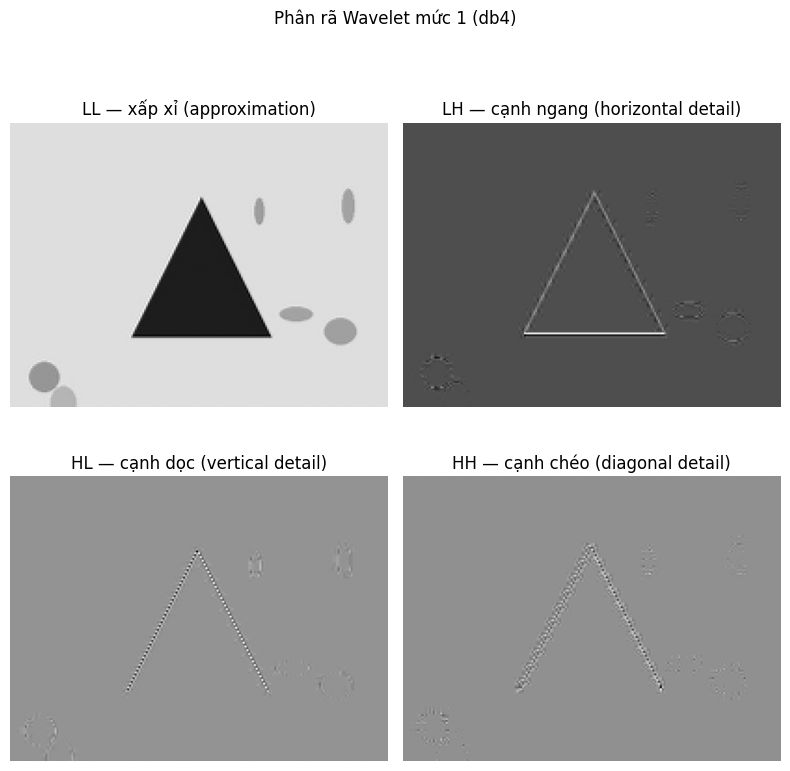

In [ ]:
fig, axes = plt.subplots(2, 2, figsize=(8, 8))
titles = {
    "LL": "LL — xấp xỉ (approximation)",
    "LH": "LH — cạnh ngang (horizontal detail)",
    "HL": "HL — cạnh dọc (vertical detail)",
    "HH": "HH — cạnh chéo (diagonal detail)",
}

for ax, name in zip(axes.ravel(), ["LL", "LH", "HL", "HH"]):
    ax.imshow(normalize_for_display(bands_l1[name]), cmap="gray")
    ax.set_title(titles[name])
    ax.axis("off")

fig.suptitle("Phân rã Wavelet mức 1 (db4)", y=1.02)
fig.tight_layout()
plt.show()


## 3. Phân rã nhiều mức (multi-level)

Áp dụng DWT lặp lại lên thành phần LL của mức trước đó. Mỗi mức tiếp theo,
ảnh xấp xỉ (LL) giảm còn một nửa kích thước mỗi chiều.

In [ ]:
max_level = max_dwt_level(image, wavelet="db4")
print("So level toi da co the phan ra cho anh nay (db4):", max_level)

level = 3
coeffs_l3 = wavedec2_image(image, wavelet="db4", level=level)
print(f"So phan tu trong coeffs (level={level}):", len(coeffs_l3))
print("Kich thuoc LL sau khi phan ra", level, "muc:", coeffs_l3[0].shape)


So level toi da co the phan ra cho anh nay (db4): 5
So phan tu trong coeffs (level=3): 4
Kich thuoc LL sau khi phan ra 3 muc: (43, 56)


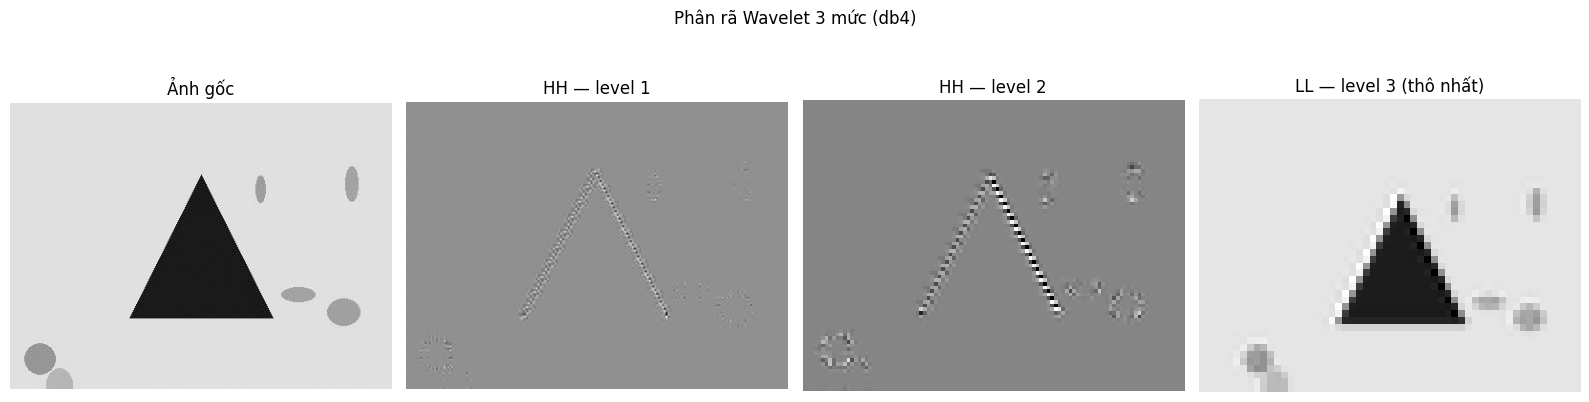

In [ ]:
fig, axes = plt.subplots(1, level + 1, figsize=(4 * (level + 1), 4))

axes[0].imshow(image, cmap="gray")
axes[0].set_title("Ảnh gốc")
axes[0].axis("off")

for lv in range(1, level + 1):
    bands = get_subbands(coeffs_l3, level=lv)
    if bands["LL"] is not None:
        display_band = bands["LL"]
        title = f"LL — level {lv} (thô nhất)"
    else:
        # Ở các mức không phải sâu nhất, minh họa bằng HH để thấy chi tiết mất dần
        display_band = bands["HH"]
        title = f"HH — level {lv}"
    axes[lv].imshow(normalize_for_display(display_band), cmap="gray")
    axes[lv].set_title(title)
    axes[lv].axis("off")

fig.suptitle(f"Phân rã Wavelet {level} mức (db4)", y=1.05)
fig.tight_layout()
plt.show()


## 4. Tái tạo ảnh (reconstruction)

Dùng `reconstruct_image` (nghịch đảo của `wavedec2_image`) để kiểm tra
tính khả nghịch của phép biến đổi — ảnh tái tạo phải gần như giống hệt
ảnh gốc (sai số rất nhỏ, do làm tròn số thực).

MSE giua anh goc va anh tai tao: 4.255714558579512e-33


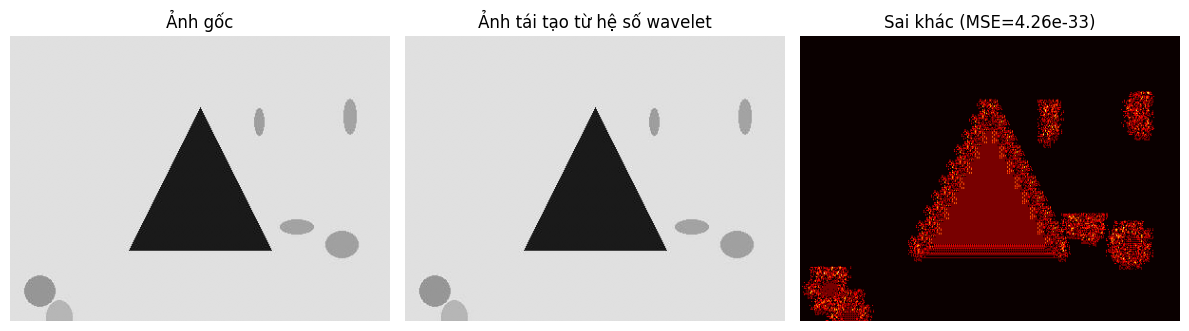

In [ ]:
reconstructed = reconstruct_image(coeffs_l1, wavelet="db4")
reconstructed = reconstructed[: image.shape[0], : image.shape[1]]

mse = np.mean((image - reconstructed) ** 2)
print("MSE giua anh goc va anh tai tao:", mse)

fig, axes = plt.subplots(1, 3, figsize=(12, 4))
axes[0].imshow(image, cmap="gray")
axes[0].set_title("Ảnh gốc")
axes[0].axis("off")

axes[1].imshow(reconstructed, cmap="gray")
axes[1].set_title("Ảnh tái tạo từ hệ số wavelet")
axes[1].axis("off")

diff = np.abs(image - reconstructed)
axes[2].imshow(diff, cmap="hot")
axes[2].set_title(f"Sai khác (MSE={mse:.2e})")
axes[2].axis("off")

fig.tight_layout()
plt.show()


## 5. So sánh nhanh độ tương đồng giữa hai ảnh

Minh họa hàm `wavelet_similarity`: so sánh ảnh gốc với (a) chính nó,
và (b) một phiên bản bị thêm nhiễu Gaussian.

Similarity(ảnh gốc, ảnh gốc)              = 1.0000
Similarity(ảnh gốc, ảnh có nhiễu)          = 0.9981
Similarity(ảnh gốc, ảnh có nhiễu, chỉ LL)  = 0.9999


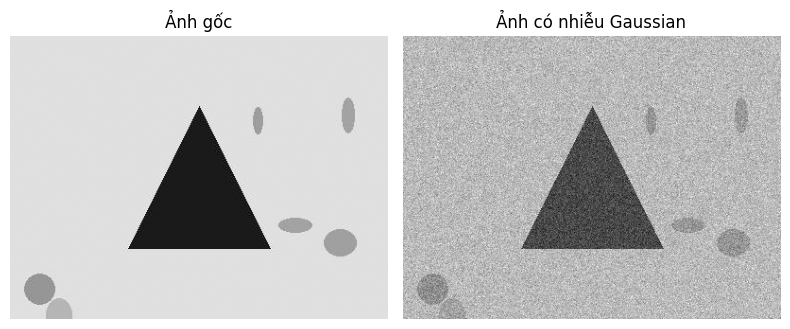

In [ ]:
rng = np.random.default_rng(0)
noisy_image = np.clip(image + rng.normal(0, 0.05, size=image.shape), 0, 1)

sim_self = wavelet_similarity(image, image, wavelet="db4", level=2)
sim_noisy = wavelet_similarity(image, noisy_image, wavelet="db4", level=2)
sim_noisy_ll_only = wavelet_similarity(image, noisy_image, wavelet="db4", level=2, use_only_ll=True)

print(f"Similarity(ảnh gốc, ảnh gốc)              = {sim_self:.4f}")
print(f"Similarity(ảnh gốc, ảnh có nhiễu)          = {sim_noisy:.4f}")
print(f"Similarity(ảnh gốc, ảnh có nhiễu, chỉ LL)  = {sim_noisy_ll_only:.4f}")

fig, axes = plt.subplots(1, 2, figsize=(8, 4))
axes[0].imshow(image, cmap="gray")
axes[0].set_title("Ảnh gốc")
axes[0].axis("off")
axes[1].imshow(noisy_image, cmap="gray")
axes[1].set_title("Ảnh có nhiễu Gaussian")
axes[1].axis("off")
fig.tight_layout()
plt.show()


## 6. Kết luận

- DWT tách ảnh thành thành phần xấp xỉ (LL) và các thành phần chi tiết
  (LH, HL, HH) theo từng hướng — đúng như lý thuyết trong
  `wavelet_transform.md`.
- Phân rã nhiều mức giúp thu được biểu diễn "đa phân giải" của ảnh.
- Phép biến đổi có thể đảo ngược gần như hoàn hảo (reconstruction MSE rất nhỏ).
- So sánh bằng hệ số **chỉ LL** cho kết quả ổn định hơn với nhiễu so với
  so sánh toàn bộ hệ số — phù hợp với lý do dùng Wavelet để so sánh ảnh
  đã trình bày trong `wavelet_theory.md`.

Bước tiếp theo: chạy `experiments/compare_wavelets.py` để so sánh định
lượng giữa nhiều loại wavelet (Haar, db2, db4, db8, sym2, sym4, coif1).